# Chapter 1: Introduction to Time Series Analysis

## 1 Learning Objectives
- Define time series data
- Identify trend, seasonality, and noise
- Understand lag and temporal dependence
- Apply decomposition techniques
- Visualize time series using Python

## What is a Time Series
A time series is a sequence of observations recorded over time where order matters.

## Time Series Data Visualization
## 1. Input data

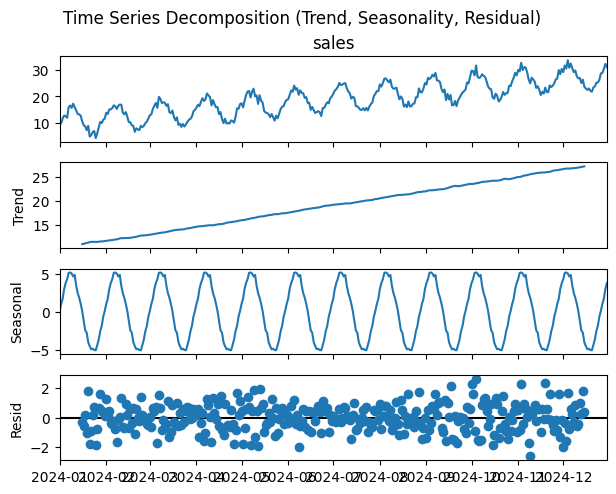

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


data = {
    "date": pd.date_range(start="2024-01-01", periods=365, freq="D"),
    "sales": (
        10 + 
        0.05 * pd.Series(range(365)) +  # trend
        5 * pd.Series(range(365)).apply(lambda x: __import__("numpy").sin(2 * __import__("numpy").pi * x / 30)) +  # seasonality
        __import__("numpy").random.normal(0, 1, 365)  # noise
    )
}

df = pd.DataFrame(data)
df.set_index("date", inplace=True)

# Decomposition (additive model)
result = seasonal_decompose(df["sales"], model="additive", period=30)

# Plot components
result.plot()
plt.suptitle("Time Series Decomposition (Trend, Seasonality, Residual)", y=1.02)
plt.show()


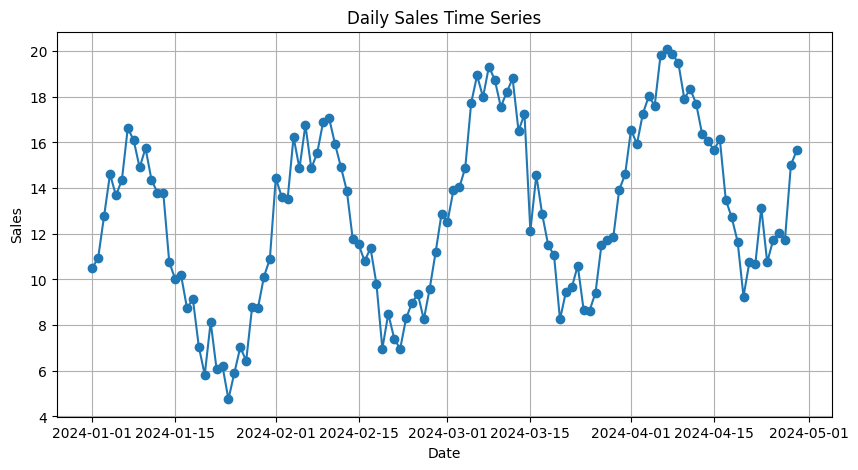

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

np.random.seed(42)

data = {
    "date": pd.date_range(start="2024-01-01", periods=120, freq="D"),
    "sales": (
        10 +
        0.05 * pd.Series(range(120)) +
        5 * pd.Series(range(120)).apply(lambda x: np.sin(2 * np.pi * x / 30)) +
        np.random.normal(0, 1, 120)
    )
}

df = pd.DataFrame(data)
df.set_index("date", inplace=True)

plt.figure(figsize=(10,5))
plt.plot(df.index, df["sales"], marker='o')
plt.title("Daily Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()


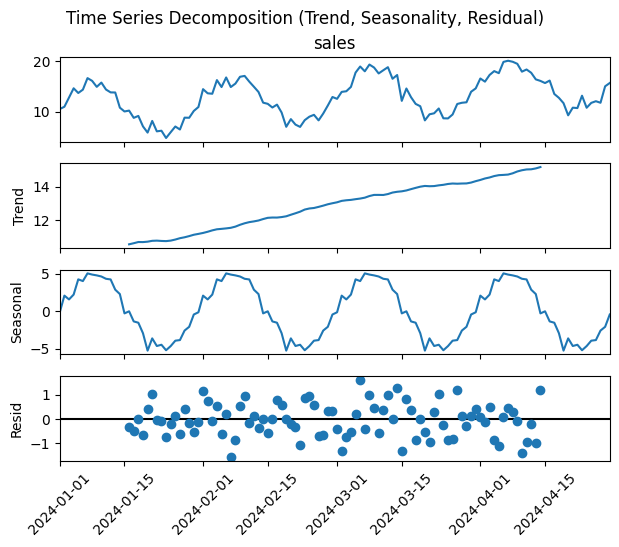

In [3]:
# Decomposition (additive model)
result = seasonal_decompose(df["sales"], model="additive", period=30)

# Plot components
result.plot()
plt.suptitle("Time Series Decomposition (Trend, Seasonality, Residual)", y=1.02)
plt.xticks(rotation=45)
plt.show()

## 2 Autocorrelation (ACF Analysis)

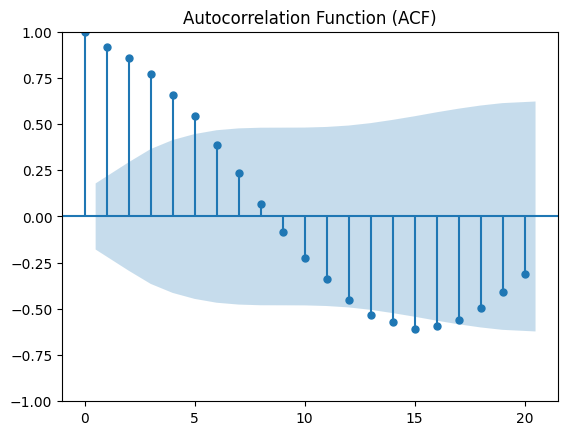

In [4]:

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df["sales"], lags=20)
plt.title("Autocorrelation Function (ACF)")
plt.show()


## 3 Differencing (Removing Trend)

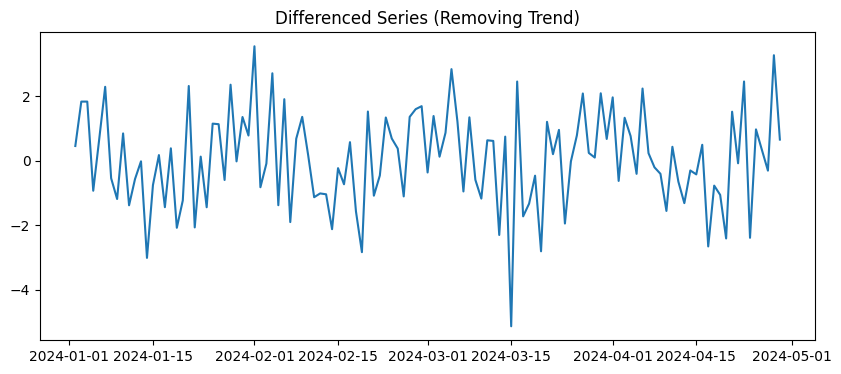

In [5]:

sales_diff = df["sales"].diff().dropna()

plt.figure(figsize=(10,4))
plt.plot(sales_diff)
plt.title("Differenced Series (Removing Trend)")
plt.show()


## 4. Autocorrelation After Differencing

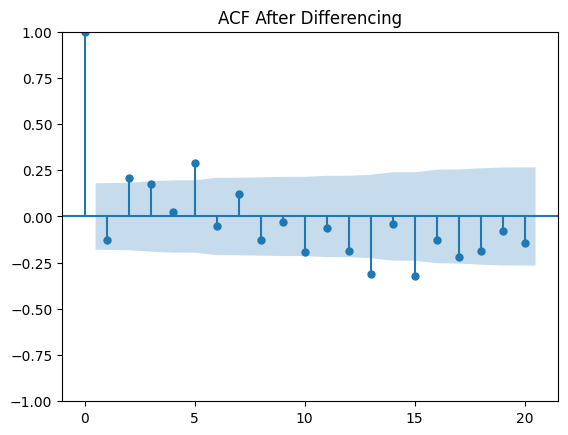

In [6]:

plot_acf(sales_diff, lags=20)
plt.title("ACF After Differencing")
plt.show()


## 5 Seasonal Temperature Data

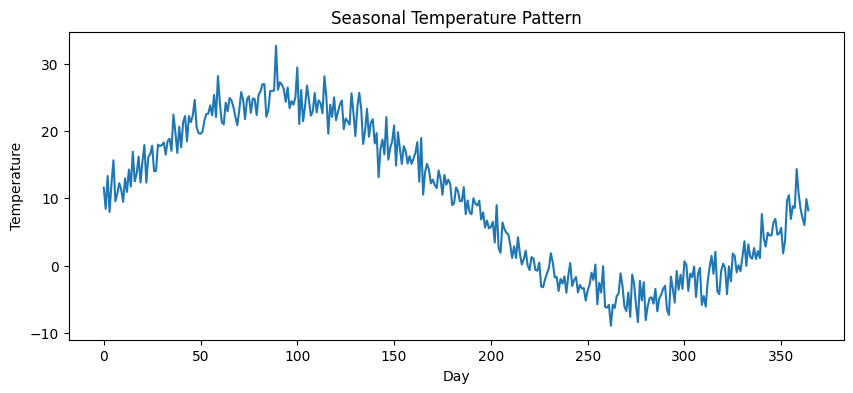

In [7]:

days = np.arange(365)
temperature = 10 + 15 * np.sin(2 * np.pi * days / 365) + np.random.normal(0, 2, 365)

plt.figure(figsize=(10,4))
plt.plot(days, temperature)
plt.title("Seasonal Temperature Pattern")
plt.xlabel("Day")
plt.ylabel("Temperature")
plt.show()


## 6. Random time series

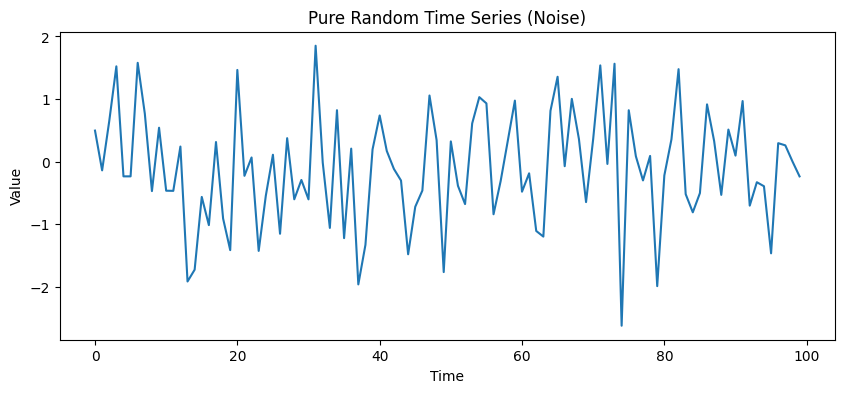

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

random_series = np.random.normal(0, 1, 100)

plt.figure(figsize=(10,4))
plt.plot(random_series)
plt.title("Pure Random Time Series (Noise)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

# This plot represents a purely random time series where values fluctuate without any visible structure.

Unlike earlier examples with trend or seasonality, this series:

has no upward or downward movement
shows no repeating pattern
cannot be predicted using past values

This type of data is often referred to as white noise and serves as an important baseline in time series analysis.